# cytoGateR Python: complete workflow using the IMMUcan data

This notebook loads the complete `data_immucan.rds` R `SpatialExperiment`, converts it to Python `AnnData`, loads the matching lineage table, and runs gating, supervised prediction, uncertainty analysis, and plotting.

In [15]:
from pathlib import Path
import subprocess
import tempfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [16]:

import cytogater as cg
from cytogater.models.knn import train_custom_knn, predict_unknown_with_knn
from cytogater.models.random_forest import train_custom_randomforest, predict_unknown_with_randomforest
from cytogater.uncertainty import calculate_uncertainty, calculate_spatial_prior_labels
from cytogater.plotting import (
    plot_labelled_cells, plot_probability_map, plot_marker_density,
    plot_confusion_matrix, plot_class_metrics, plot_celltype_tree,
)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 30)
SAVE_OUTPUT = False  # Set True to write the final .h5ad file.

## 1. Convert the IMMUcan R `SpatialExperiment` to `AnnData`

Set `dataset_path` below to test another `.rds` dataset. The conversion cell exports all cells, expression values, cell metadata, and spatial coordinates.

In [17]:
dataset_path = Path('/users/stgrad/lijiay/PRJ-cytogater/20260627-R_package_tests-LY/in/datasets_rds/breast_MIBI-TOF_sce.rds')
if not dataset_path.is_file():
    raise FileNotFoundError(f'Dataset not found: {dataset_path}')

conversion_dir = Path(tempfile.mkdtemp(prefix='cytogater-r-conversion-'))
r_code = r'''
args <- commandArgs(trailingOnly = TRUE)
suppressPackageStartupMessages(library(SpatialExperiment))
spe_all <- readRDS(args[1])
spe <- spe_all
expr <- t(as.matrix(assay(spe, "exprs")))
meta <- as.data.frame(colData(spe))
meta[] <- lapply(meta, function(x) if (is.factor(x)) as.character(x) else x)
write.csv(expr, file.path(args[2], "expression.csv"), quote = FALSE)
write.csv(meta, file.path(args[2], "obs.csv"), quote = TRUE)
if (inherits(spe, "SpatialExperiment")) {
    coords <- as.data.frame(spatialCoords(spe))
    write.csv(coords, file.path(args[2], "spatial.csv"), quote = FALSE)
}
'''
conversion = subprocess.run([
    'Rscript', '-e', r_code,
    str(dataset_path),
    str(conversion_dir),
], capture_output=True, text=True)
if conversion.returncode != 0:
    raise RuntimeError(f'R conversion failed:\n{conversion.stderr}')

expression = pd.read_csv(conversion_dir / 'expression.csv', index_col=0)
obs = pd.read_csv(conversion_dir / 'obs.csv', index_col=0)
spatial_path = conversion_dir / 'spatial.csv'
HAS_SPATIAL = spatial_path.is_file()
obs.index = expression.index.astype(str)

adata = ad.AnnData(expression.to_numpy(dtype=float), obs=obs)
adata.obs_names = expression.index.astype(str)
adata.var_names = expression.columns.astype(str)
adata.layers['exprs'] = adata.X.copy()
if HAS_SPATIAL:
    adata.obsm['spatial'] = pd.read_csv(spatial_path, index_col=0).to_numpy()
else:
    print('SingleCellExperiment detected: spatial analyses and plots will be skipped.')
adata

SingleCellExperiment detected: spatial analyses and plots will be skipped.


AnnData object with n_obs × n_vars = 69672 × 40
    obs: 'Point_Num', 'CohortNumber', 'label', 'cell_size', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'Tissue_Type', 'Status', 'Tissue', 'sublineage', 'phenotype', 'compartment', 'celllineage', 'sublineage_code', 'phenotype_code', 'compartment_code', 'celllineage_code', 'manual_gating_cellineage', 'manual_gating_subineage', 'manual_gating_phenotype', 'innerduct_mask', 'distal_mask', 'stroma_mask', 'periph_mask', 'epi_mask', 'duct_mask', 'myoep_mask', 'ERstatus', 'HER2status', 'ARstatus', 'Ki67status', 'pS6status', 'GLUT1status', 'HIF1astatus', 'COX2status', 'CD36status', 'CD44status', 'PD1status', 'PDL1status', 'IDO1status', 'GZMBstatus', 'ECADstatus', 'MMP9status', 'VIMstatus', 'FAPstatus', 'HLADRstatus', 'CD3status', 'SMAstatus', 'COLIstatus', 'CK5status', 'CK7status', 'P63status', 'myoep_dist_label', 'myoep_dist_MinDist', 'myoep_dist_MaxDist', 'myoep_dist_MedDist', 'myoep_dist_MeanDist', 'celltype_c

In [18]:
print(f'{adata.n_obs:,} cells × {adata.n_vars} markers')
metadata_columns = [
    column for column in ['sample_id', 'image_name', 'cell_type']
    if column in adata.obs
]
display(adata.obs[metadata_columns].head())
display(pd.Series(adata.var_names, name='marker').to_frame().T)

69,672 cells × 40 markers


,sample_id,cell_type
70001,3,TUMOR
70003,3,TUMOR
70006,3,TUMOR
70007,3,TUMOR
70008,3,TUMOR


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
marker,COLI,CD14,P63,pS6,CD4,HLADRDPDQ,GZMB,Tryptase,ECAD,AR,...,Ki67,CK5,COX2,CD20,FOXP3,IDO1,CD36,ER,Ca40,CD31


## 2. Load the marker lineage table

The R-style CSV uses `1` for positive markers and `-1` for negative markers. This cell converts it to the list-column format expected by the Python gating functions.

In [19]:
lineage_path = Path('/users/stgrad/lijiay/PRJ-cytogater/20260627-R_package_tests-LY/in/lineage_tables_csv/breast_MIBI-TOF_sce.csv')
if not lineage_path.is_file():
    raise FileNotFoundError(f'Lineage table not found: {lineage_path}')

lineage_wide = pd.read_csv(lineage_path)
marker_columns = lineage_wide.columns.drop('Populations')
lineage_table = pd.DataFrame({
    'cell_type': lineage_wide['Populations'].astype(str),
    'pos_markers': lineage_wide[marker_columns].eq(1).apply(
        lambda row: marker_columns[row].tolist(), axis=1,
    ),
    'neg_markers': lineage_wide[marker_columns].eq(-1).apply(
        lambda row: marker_columns[row].tolist(), axis=1,
    ),
})
lineage_table

,cell_type,pos_markers,neg_markers
0,TUMOR,"[PanKRT, ECAD, CK7, CK5, HER2, ER, AR]","[CD31, CD45]"
1,MYOEP,"[CK5, SMA, P63]","[CD31, CD45]"
2,FIBROBLAST,"[VIM, COLI, FAP]","[PanKRT, ECAD, CK7, CD31, CD45]"
3,ENDO,[CD31],"[PanKRT, ECAD, SMA, COLI, FAP, CD45]"
4,BCELL,[CD20],"[PanKRT, ECAD, CD3, CD14, CD68, CD11c]"
5,TCELL,"[CD3, CD45]","[PanKRT, ECAD, CD20, CD4, CD8, CD14, CD68, CD11c]"
6,CD4T,"[CD3, CD45, CD4]","[PanKRT, ECAD, CD20, CD8, CD14, CD68]"
7,CD8T,"[CD3, CD45, CD8, GZMB]","[PanKRT, ECAD, CD20, CD4, CD14, CD68]"
8,NEUT,"[MPO, MMP9]","[PanKRT, ECAD, CD20, CD3, CD14, CD68]"
9,MAST,[Tryptase],"[PanKRT, ECAD, CD20, CD3, CD14, CD68]"


## 3. Run gating

Both algorithms are shown for comparison, but supervised training must use **one explicit gating result**. Below, `tree_result` is selected as `gating_result`:

`tree probabilities → 98th-percentile cutoff labels → consensus-cleaned reference → prediction`

To use soft gating instead, change only `gating_result = soft_result`.

In [20]:
soft_result = cg.run_soft_gating(
    adata, lineage_table, assay_name='exprs', unknown_thresh=0.4,
)
tree_result = cg.run_tree_gating(
    adata, lineage_table, assay_name='exprs', max_depth=6,
    min_cells=100, min_score=0.05, uncert_thresh=0.25,
    neg_strength=0.5, cutoff_method='equal_posteriors',
    workers=8, gmm_model_names=None,
)

# This object supplies the probability matrix used to create training labels.
gating_result = tree_result
display(pd.DataFrame({
    'soft_label': pd.Series(soft_result['labels']).value_counts(),
    'tree_label': pd.Series(tree_result['hard_label']).value_counts(),
}).fillna(0).astype(int))

,soft_label,tree_label
APC,5021,1945
BCELL,159,208
CD4T,450,910
CD8T,101,385
DC,44,187
ENDO,475,329
FIBROBLAST,2283,3350
IMMUNEOTHER,1443,731
MACS,170,348
MAST,727,583


In [21]:
tree_result['prob_mat']

,TUMOR,MYOEP,FIBROBLAST,ENDO,BCELL,TCELL,CD4T,CD8T,NEUT,MAST,MONO,MACS,DC,APC,MONODC,IMMUNEOTHER
70001,0.515483,0.069568,0.004313,0.000455,0.000007,0.004159,0.003168,0.002555,0.000012,0.000010,0.005264,0.002679,0.003554,0.004869,0.003244,0.002886
70003,0.356148,0.017474,0.015470,0.002078,0.000004,0.002366,0.003381,0.002727,0.000013,0.000011,0.005599,0.002849,0.068750,0.005179,0.056105,0.003661
70006,0.323392,0.237308,0.004067,0.000539,0.000007,0.004390,0.003343,0.002697,0.000013,0.000011,0.005555,0.002827,0.003750,0.005139,0.003423,0.003052
70007,0.438142,0.017532,0.004181,0.000523,0.000007,0.004263,0.003247,0.002619,0.000013,0.000010,0.005395,0.002746,0.009672,0.012810,0.007385,0.003138
70008,0.234668,0.009608,0.017794,0.035551,0.000007,0.004192,0.003193,0.040054,0.000012,0.000010,0.002908,0.001480,0.003582,0.002690,0.001792,0.000833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38134,0.024319,0.015124,0.218397,0.001321,0.000023,0.085417,0.070670,0.057378,0.000043,0.000036,0.079722,0.029699,0.217168,0.293038,0.177037,0.079712
38137,0.014358,0.008929,0.013341,0.000947,0.000024,0.237371,0.190309,0.158300,0.000045,0.000037,0.243370,0.009758,0.165569,0.207303,0.130247,0.296297
38148,0.015199,0.009453,0.050068,0.001003,0.000024,0.220834,0.179114,0.148445,0.000045,0.000037,0.219230,0.009758,0.237460,0.317100,0.165123,0.258829
38169,0.016081,0.010001,0.176294,0.000545,0.000024,0.118147,0.298915,0.079772,0.000045,0.000037,0.200624,0.009758,0.159700,0.199606,0.126303,0.120437


In [22]:
# pd.Series(tree_result['prob_mat']['Stroma']).value_counts()

In [23]:
pd.Series(soft_result['labels']).value_counts()

Unknown        41447
TUMOR          13522
APC             5021
FIBROBLAST      2283
MYOEP           1809
MONO            1627
IMMUNEOTHER     1443
MAST             727
ENDO             475
CD4T             450
TCELL            238
MACS             170
BCELL            159
NEUT             127
CD8T             101
DC                44
MONODC            29
Name: count, dtype: int64

In [24]:
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# plot_labelled_cells(adata, 'cell_type', ax=axes[0], s=3, title='Published reference labels')
# plot_labelled_cells(adata, 'cell_type_hard', ax=axes[1], s=3, title='Python tree-gating labels')
# plot_probability_map(adata, 'P_Tumor', ax=axes[2], s=3, title='Tumor probability')
# plt.tight_layout()

In [25]:
if not HAS_SPATIAL:
    print('Spatial label maps skipped: this dataset has no spatial coordinates.')
else:
    sample_id = str(adata.obs['sample_id'].iloc[0])

    adata_sample = adata[
        adata.obs['sample_id'].astype(str) == sample_id
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    plot_labelled_cells(
        adata_sample,
        'cell_type',
        ax=axes[0],
        s=3,
        title=f'{sample_id}: reference labels',
    )

    plot_labelled_cells(
        adata_sample,
        'cell_type_hard',
        ax=axes[1],
        s=3,
        title=f'{sample_id}: tree-gating labels',
    )

    tumor_label = next(
        (label for label in lineage_table['cell_type'] if label.lower() == 'tumor'),
        lineage_table['cell_type'].iloc[0],
    )
    tumor_probability = 'P_' + tumor_label.replace(' ', '_')
    plot_probability_map(
        adata_sample,
        tumor_probability,
        ax=axes[2],
        s=3,
        title=f'{sample_id}: Tumor probability',
    )

    plt.tight_layout()

Spatial label maps skipped: this dataset has no spatial coordinates.


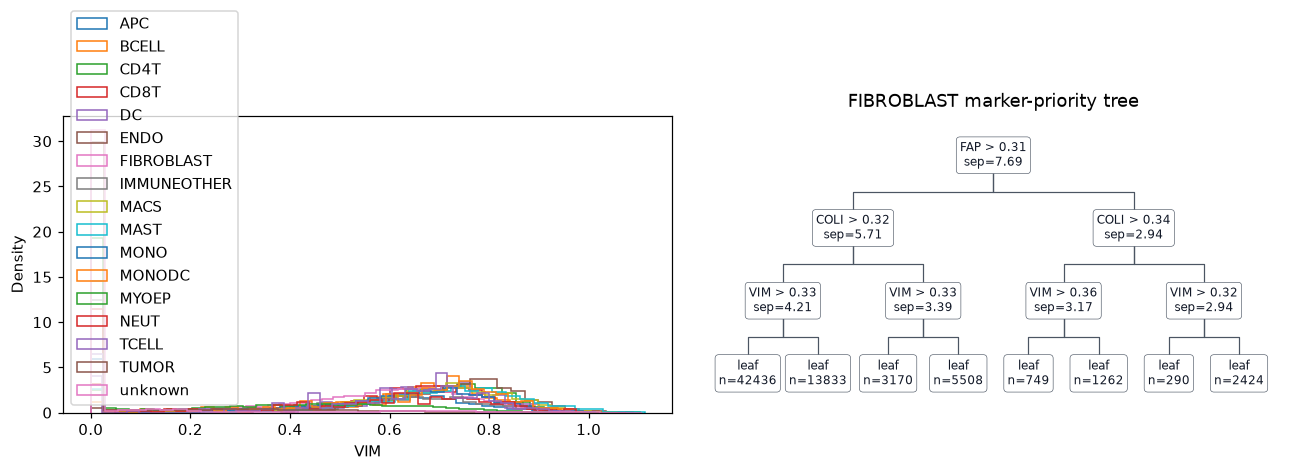

In [26]:
example_cell_type = next(
    (label for label in lineage_table['cell_type'] if label == 'FIBROBLAST'),
    lineage_table['cell_type'].iloc[0],
)
example_cell_type
example_markers = lineage_table.loc[
    lineage_table['cell_type'] == example_cell_type, 'pos_markers'
].iloc[0]
example_marker = example_markers[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_marker_density(adata, example_marker, label_col='cell_type', ax=axes[0])
plot_celltype_tree(
    tree_result['trees'][example_cell_type],
    title=f'{example_cell_type} marker-priority tree', ax=axes[1],
)
plt.tight_layout()

## 4. Create training data from the selected gating result

`apply_cutoff_labels()` computes a separate 98th-percentile cutoff for each cell-type probability. A cell becomes a training candidate only when it passes exactly one cutoff. Cells passing zero or multiple cutoffs remain `Unknown`, matching the R vignette.

In [27]:
gating_result = cg.apply_cutoff_labels(
    gating_result,
    cutoff_fn=cg.prob_quantile_cutoff,
    label_col='cutoff_label',
    unknown_label='Unknown',
)
adata = gating_result['spe']
reference_counts = adata.obs['cutoff_label'].value_counts(dropna=False)
# Validate against the probability matrix actually used, not notebook state
# from a lineage_table cell that may have been rerun independently.
allowed_labels = set(map(str, gating_result['prob_mat'].columns)) | {'Unknown'}
observed_labels = set(adata.obs['cutoff_label'].dropna().astype(str).unique())
unexpected_labels = observed_labels - allowed_labels
if unexpected_labels:
    raise RuntimeError(
        f'Unexpected cutoff labels: {sorted(unexpected_labels)}. '
        'Restart the kernel and run all cells so the updated package and '
        'gating_result are loaded together.'
    )
if adata.obs['cutoff_label'].isna().any():
    raise RuntimeError('cutoff_label contains missing values; rerun gating and cutoff creation.')
print(f"Reference cells: {(adata.obs['cutoff_label'] != 'Unknown').sum():,} / {adata.n_obs:,}")
display(reference_counts)

Reference cells: 15,792 / 69,672


cutoff_label
Unknown        53880
BCELL          10191
TUMOR           1289
MYOEP           1262
NEUT             452
MONO             421
MAST             372
CD4T             371
MACS             320
ENDO             318
CD8T             298
FIBROBLAST       184
MONODC            99
APC               74
DC                69
IMMUNEOTHER       56
TCELL             16
Name: count, dtype: int64

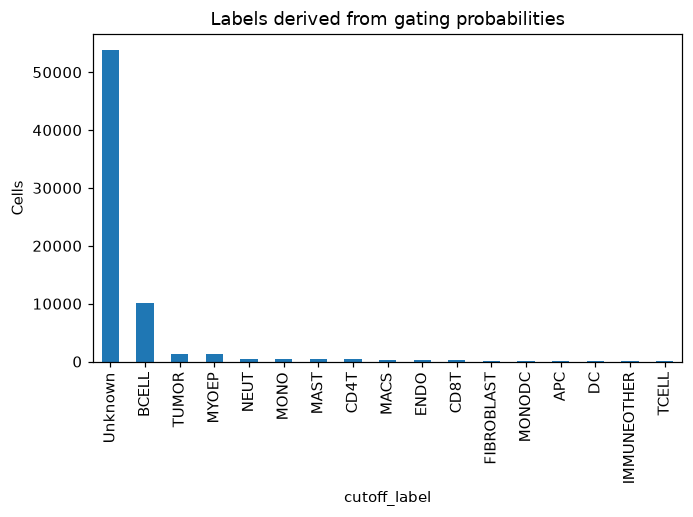

In [28]:
if HAS_SPATIAL:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    reference_counts.plot.bar(ax=axes[0], title='Labels derived from gating probabilities')
    axes[0].set_ylabel('Cells')
    plot_labelled_cells(
        adata, 'cutoff_label', ax=axes[1], s=3,
        title='Gating-derived training reference',
    )
else:
    ax = reference_counts.plot.bar(title='Labels derived from gating probabilities')
    ax.set_ylabel('Cells')
plt.tight_layout()

## 5. Clean the gating-derived reference and predict unknown cells

This cell reproduces the R ablation workflows in `1.2-rf-ML.R` and `1.3-knn-ML.R`: a 0.99 cutoff, `Unassigned` unknown labels, positive lineage markers, and ten cleaning repeats. KNN fills from the cleaned reference; RF follows the R script and fills cells marked `Unassigned` in `core_group`.

In [29]:
benchmark_features = sorted({
    marker
    for markers in lineage_table['pos_markers']
    for marker in markers
    if marker in adata.var_names
})
benchmark_gating_input = {
    **gating_result,
    'spe': gating_result['spe'].copy(),
    'prob_mat': gating_result['prob_mat'].copy(),
}
benchmark_gating = cg.apply_cutoff_labels(
    benchmark_gating_input,
    cutoff_fn=lambda values: cg.prob_quantile_cutoff(values, prob=0.99),
    label_col='core_group',
    unknown_label='Unassigned',
)

# R 1.3-knn-ML.R
knn_adata = benchmark_gating['spe'].copy()
knn_fit = train_custom_knn(
    knn_adata, label_col='core_group', assay_name='exprs',
    unknown_label='Unassigned', features=benchmark_features,
    cv_folds=5, repeats=10, agreement_thresh=0.8, k=5,
    method='pearson', seed=123, chunk_size=5_000,
)
knn_result = predict_unknown_with_knn(
    knn_adata, knn_fit, assay_name='exprs',
    label_col='cleaned_core_label', out_col='knn_stage1_label',
    threshold=0.6, k=20, unknown_label='Unassigned',
    unassigned_label='Unassigned', chunk_size=5_000,
)

# R 1.2-rf-ML.R
rf_adata = benchmark_gating['spe'].copy()
rf_fit = train_custom_randomforest(
    rf_adata, label_col='core_group', assay_name='exprs',
    unknown_label='Unassigned', features=benchmark_features,
    num_trees=200, cv_folds=5, repeats=10,
    agreement_thresh=0.8, num_threads=2, seed=123,
)
rf_result = predict_unknown_with_randomforest(
    rf_adata, rf_fit['model'], assay_name='exprs',
    label_col='core_group', out_col='rf_stage1_label',
    threshold=0.5, unknown_label='Unassigned',
    unassigned_label='Unassigned',
)
display(knn_adata.obs[['cell_type', 'core_group', 'cleaned_core_label', 'knn_stage1_label']].head())
display(rf_adata.obs[['cell_type', 'core_group', 'cleaned_core_label', 'rf_stage1_label']].head())

/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (


,cell_type,core_group,cleaned_core_label,knn_stage1_label
70001,TUMOR,Unassigned,Unassigned,TUMOR
70003,TUMOR,Unassigned,Unassigned,TUMOR
70006,TUMOR,Unassigned,Unassigned,MYOEP
70007,TUMOR,Unassigned,Unassigned,TUMOR
70008,TUMOR,Unassigned,Unassigned,TUMOR


,cell_type,core_group,cleaned_core_label,rf_stage1_label
70001,TUMOR,Unassigned,Unassigned,TUMOR
70003,TUMOR,Unassigned,Unassigned,TUMOR
70006,TUMOR,Unassigned,Unassigned,MYOEP
70007,TUMOR,Unassigned,Unassigned,TUMOR
70008,TUMOR,Unassigned,Unassigned,TUMOR


## 6. Evaluate predictions

In [30]:
tree_metrics = cg.calculate_f1(adata, ref_col='cell_type', pred_col='cell_type_hard')
knn_metrics = cg.calculate_f1(knn_adata, ref_col='cell_type', pred_col='knn_stage1_label')
rf_metrics = cg.calculate_f1(rf_adata, ref_col='cell_type', pred_col='rf_stage1_label')
display(pd.concat({'tree': tree_metrics, 'kNN': knn_metrics, 'random forest': rf_metrics}, names=['method']))

Category  Precision  Recall  F1_Score  Cell_Count
method                                                            
tree          0       APC      0.443   0.543     0.488        1587
              1     BCELL      0.909   0.286     0.435         661
              2      CD4T      0.866   0.607     0.714        1298
              3      CD8T      0.852   0.395     0.539         831
              4        DC      0.642   0.667     0.654         180
...                   ...        ...     ...       ...         ...
random forest 11   MONODC      0.056   0.064     0.060         346
              12    MYOEP      0.617   0.274     0.379        5687
              13     NEUT      0.427   0.687     0.527         540
              14    TCELL      0.303   0.897     0.453         224
              15    TUMOR      0.965   0.352     0.516       37620

[49 rows x 5 columns]

In [31]:
display(tree_metrics)

,Category,Precision,Recall,F1_Score,Cell_Count
0,APC,0.443,0.543,0.488,1587
1,BCELL,0.909,0.286,0.435,661
2,CD4T,0.866,0.607,0.714,1298
3,CD8T,0.852,0.395,0.539,831
4,DC,0.642,0.667,0.654,180
5,ENDO,0.951,0.194,0.322,1617
6,FIBROBLAST,0.832,0.404,0.544,6902
7,IMMUNEOTHER,0.490,0.224,0.307,1601
8,MACS,0.198,0.068,0.101,1017
9,MAST,0.950,0.501,0.656,1105


In [32]:
display(rf_metrics)

,Category,Precision,Recall,F1_Score,Cell_Count
0,APC,0.152,0.033,0.055,1587
1,BCELL,0.677,0.902,0.773,661
2,CD4T,0.938,0.488,0.642,1298
3,CD8T,0.867,0.566,0.685,831
4,DC,0.216,0.694,0.329,180
5,ENDO,0.852,0.625,0.721,1617
6,FIBROBLAST,0.859,0.117,0.205,6902
7,IMMUNEOTHER,0.058,0.007,0.012,1601
8,MACS,0.072,0.032,0.045,1017
9,MAST,0.899,0.615,0.731,1105


In [33]:
display(knn_metrics)

,Category,Precision,Recall,F1_Score,Cell_Count
0,APC,0.040,0.007,0.012,1587
1,BCELL,0.781,0.773,0.777,661
2,CD4T,0.771,0.653,0.707,1298
3,CD8T,0.853,0.664,0.747,831
4,DC,0.078,0.761,0.141,180
5,ENDO,0.335,0.876,0.484,1617
6,FIBROBLAST,0.739,0.387,0.508,6902
7,IMMUNEOTHER,0.025,0.003,0.006,1601
8,MACS,0.060,0.038,0.047,1017
9,MAST,0.832,0.729,0.777,1105


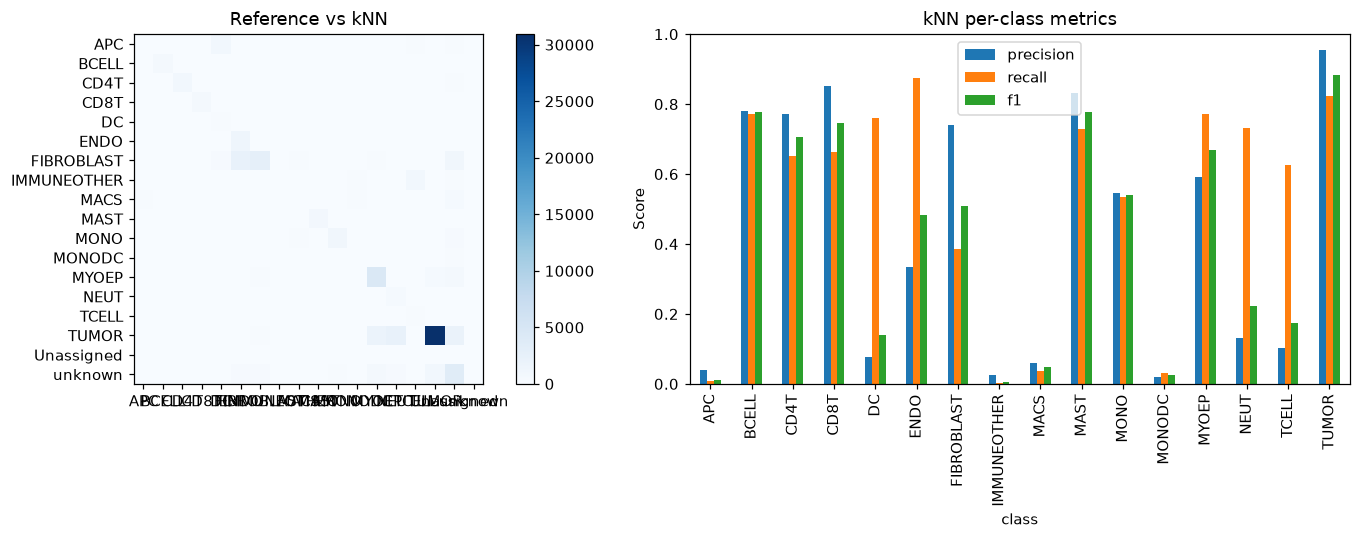

In [34]:
# The aligned KNN result is stored in knn_adata, not the original adata.
confusion = cg.label_confusion_matrix(
    knn_adata,
    'cell_type',
    'knn_stage1_label',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(
    confusion,
    title='Reference vs kNN',
    ax=axes[0],
)
plot_class_metrics(
    knn_metrics.rename(columns={
        'Category': 'class',
        'Precision': 'precision',
        'Recall': 'recall',
        'F1_Score': 'f1',
    }),
    title='kNN per-class metrics',
    ax=axes[1],
)
plt.tight_layout()

## 7. Probability uncertainty and protected spatial priors

The packaged R demo already contains a complete `KNN_P_*` matrix. Using it here demonstrates uncertainty and spatial adjustment for every cell without filling artificial probabilities for reference cells.

In [35]:
full_probabilities = pd.concat([
    knn_fit['core_prob_mat'],
    knn_result['prob_mat'],
]).reindex(adata.obs_names)
if full_probabilities.empty or full_probabilities.isna().all(axis=1).any():
    missing = full_probabilities.isna().all(axis=1).sum()
    raise RuntimeError(f'kNN probabilities are missing for {missing:,} cells.')

if HAS_SPATIAL:
    uncertainty = calculate_uncertainty(
        full_probabilities, adata, sample_col='sample_id', k_spatial=15,
    )
    adata.obs[uncertainty.columns[1:]] = uncertainty.iloc[:, 1:]
    calculate_spatial_prior_labels(
        adata, full_probabilities, k_spatial=15,
        lambda_=0.2, protect_threshold=0.85,
    )
    display(uncertainty.describe())
else:
    uncertainty = None
    print('Spatial uncertainty and spatial-prior labels skipped.')

Spatial uncertainty and spatial-prior labels skipped.


In [36]:
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# plot_probability_map(adata, 'entropy', ax=axes[0], s=3, title='Normalized entropy')
# plot_probability_map(adata, 'spatial_discordance', ax=axes[1], s=3, title='Spatial discordance')
# plot_labelled_cells(adata, 'knn_spatial_label', ax=axes[2], s=3, title='Spatial-prior label')
# plt.tight_layout()

In [37]:
if not HAS_SPATIAL:
    print('Spatial uncertainty plots skipped: this dataset has no coordinates.')
else:
    sample_id = str(adata.obs['sample_id'].iloc[0])
    sample_mask = adata.obs['sample_id'].astype(str) == sample_id
    adata_sample = adata[sample_mask].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    plot_probability_map(
        adata_sample, 'entropy',
        ax=axes[0], s=3, title=f'{sample_id}: normalized entropy',
    )
    plot_probability_map(
        adata_sample, 'spatial_discordance',
        ax=axes[1], s=3, title=f'{sample_id}: spatial discordance',
    )
    plot_labelled_cells(
        adata_sample, 'knn_spatial_label',
        ax=axes[2], s=3, title=f'{sample_id}: spatial-prior label',
    )
    plt.tight_layout()

Spatial uncertainty plots skipped: this dataset has no coordinates.


## 8. Save the converted and annotated data

Tree dictionaries are ordinary Python return objects. The cell-level results are stored in `adata.obs` and probability matrices in `adata.obsm`.

In [38]:
output_path = Path.cwd() / 'cytogater_r_demo_python.h5ad'
if SAVE_OUTPUT:
    adata.write_h5ad(output_path)
    print(f'Saved {output_path}')
else:
    print('Set SAVE_OUTPUT = True in the first cell to save:', output_path)

Set SAVE_OUTPUT = True in the first cell to save: /dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/examples/cytogater_r_demo_python.h5ad


## 9. Test hierarchical kNN

This diagnostic uses all high-confidence reference cells but predicts a small subset first. Set `HIERARCHICAL_TEST_N_CELLS = None` only after the test succeeds to annotate the complete dataset.

In [39]:
import time
import pandas as pd

# Match 20260715-new_ablation-LY/src/1.3-knn-ML.R and 1.4-hier-ML.R.
# Start with a subset; use None only for the final full benchmark.
HIERARCHICAL_TEST_N_CELLS = None
HIERARCHICAL_OUT_COL = 'hierarchical_label'

# R benchmark: regenerate the core group at the 0.99 probability quantile
# and use Unassigned consistently during KNN reference cleaning. Work on a
# copy so this parity test does not overwrite earlier notebook results.
hierarchical_gating_input = {
    **gating_result,
    'spe': gating_result['spe'].copy(),
    'prob_mat': gating_result['prob_mat'].copy(),
}
hierarchical_gating_result = cg.apply_cutoff_labels(
    hierarchical_gating_input,
    cutoff_fn=lambda values: cg.prob_quantile_cutoff(values, prob=0.99),
    label_col='core_group',
    unknown_label='Unassigned',
)
hierarchical_adata = hierarchical_gating_result['spe']
hierarchical_features = sorted({
    marker
    for markers in lineage_table['pos_markers']
    for marker in markers
    if marker in hierarchical_adata.var_names
})
print(hierarchical_adata.obs['core_group'].value_counts(dropna=False))

# 1. Clean the cutoff-derived training labels using repeated CV.
started = time.perf_counter()
hier_knn_fit = cg.train_custom_knn(
    hierarchical_adata,
    label_col='core_group',
    assay_name='exprs',
    unknown_label='Unassigned',
    features=hierarchical_features,
    cv_folds=5,
    repeats=10,
    agreement_thresh=0.8,
    k=5,
    method='pearson',
    seed=123,
    chunk_size=5_000,
)
print(f'Cleaned reference: {time.perf_counter() - started:.1f} seconds')
print(hierarchical_adata.obs['cleaned_core_label'].value_counts(dropna=False))

# 2. Build the cell-type hierarchy and its node-specific references.
started = time.perf_counter()
hierarchy_tree = cg.build_lineage_hierarchy(
    hierarchical_adata, label_col='cleaned_core_label', assay_name='exprs'
)
hierarchy_marker_stats = cg.fit_marker_stats(
    hierarchical_adata, hierarchical_features, assay_name='exprs'
)
hierarchy_reference = cg.build_hierarchical_reference(
    hierarchical_adata,
    hierarchy_tree,
    marker_stats=hierarchy_marker_stats,
    label_col='cleaned_core_label',
    top_n=None,
    assay_name='exprs',
    unknown_label='Unassigned',
)
print(f'Built hierarchy/reference: {time.perf_counter() - started:.1f} seconds')
print('Hierarchy leaf labels:', hierarchy_tree['labels'])
print('Internal nodes:', len(hierarchy_reference) - 1)

# 3. Predict a subset while retaining the full reference built above.
if HIERARCHICAL_TEST_N_CELLS is None:
    hierarchical_test = hierarchical_adata.copy()
else:
    n_test = min(HIERARCHICAL_TEST_N_CELLS, hierarchical_adata.n_obs)
    hierarchical_test = hierarchical_adata[:n_test].copy()

started = time.perf_counter()
cg.predict_hierarchical_knn_recursive(
    hierarchical_test,
    hierarchy_reference,
    hierarchy_tree,
    assay_name='exprs',
    threshold=0.6,
    agreement_threshold=0.8,
    k=20,
    repeats=10,
    dist_methods=('pearson', 'cosine'),
    out_col=HIERARCHICAL_OUT_COL,
    chunk_size=25_000,
)
prediction_seconds = time.perf_counter() - started
print(
    f'Predicted {hierarchical_test.n_obs:,} cells in {prediction_seconds:.1f} seconds '
    f'({prediction_seconds / max(hierarchical_test.n_obs, 1):.4f} seconds/cell)'
)

# 4. Inspect outputs and compare with the existing annotation when available.
counts = hierarchical_test.obs[HIERARCHICAL_OUT_COL].value_counts(dropna=False)
display(counts.to_frame('cells'))
unassigned_rate = hierarchical_test.obs[HIERARCHICAL_OUT_COL].eq('Unassigned').mean()
print(f'Unassigned: {unassigned_rate:.1%}')

if 'cell_type' in hierarchical_test.obs:
    comparison = pd.crosstab(
        hierarchical_test.obs['cell_type'],
        hierarchical_test.obs[HIERARCHICAL_OUT_COL],
        rownames=['Existing cell_type'],
        colnames=['Hierarchical kNN'],
        normalize='index',
    ).mul(100).round(1)
    display(comparison)
    display(cg.calculate_f1(
        hierarchical_test,
        ref_col='cell_type',
        pred_col=HIERARCHICAL_OUT_COL,
    ))


core_group
Unassigned     63000
TUMOR            678
MYOEP            678
ENDO             673
FIBROBLAST       655
MAST             606
BCELL            473
NEUT             459
CD4T             437
DC               356
CD8T             331
TCELL            312
MONO             285
MACS             247
MONODC           179
APC              174
IMMUNEOTHER      129
Name: count, dtype: int64
Cleaned reference: 101.1 seconds
cleaned_core_label
Unassigned     63505
TUMOR            677
MYOEP            668
ENDO             662
FIBROBLAST       652
MAST             597
CD4T             430
NEUT             418
BCELL            388
DC               329
CD8T             306
MONO             265
TCELL            259
MACS             215
MONODC           130
APC               91
IMMUNEOTHER       80
Name: count, dtype: int64
Built hierarchy/reference: 33.1 seconds
Hierarchy leaf labels: ['Unassigned', 'TUMOR', 'MYOEP', 'FIBROBLAST', 'MACS', 'DC', 'MONO', 'APC', 'MAST', 'NEUT', 'CD8T', 'CD4T', 

/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (
/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (
/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (
/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (
/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in divide
  scores = (a @ b.T) / (
/dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/src/cytogater/models/knn.py:65: RuntimeWarning: invalid value encountered in 

Predicted 69,672 cells in 2881.7 seconds (0.0414 seconds/cell)


,cells
hierarchical_label,
TUMOR,32695
Unassigned,7389
MYOEP,7253
ENDO,4505
FIBROBLAST,4498
NEUT,2945
MONO,1961
DC,1901
TCELL,1348


Unassigned: 10.6%


Hierarchical kNN,APC,BCELL,CD4T,CD8T,DC,ENDO,FIBROBLAST,IMMUNEOTHER,MACS,MAST,MONO,MONODC,MYOEP,NEUT,TCELL,TUMOR,Unassigned
Existing cell_type,,,,,,,,,,,,,,,,,
APC,0.4,0.3,0.0,0.0,63.8,2.1,5.5,0.0,0.6,0.0,5.1,0.4,3.7,0.1,5.1,0.7,12.3
BCELL,1.1,76.7,0.8,1.7,1.2,1.4,0.2,0.3,0.9,0.0,2.3,1.2,0.2,0.3,0.9,0.2,10.9
CD4T,2.8,3.5,66.6,1.0,5.4,0.5,0.2,0.1,0.1,0.0,0.0,2.3,1.6,0.0,0.8,0.9,14.3
CD8T,0.0,0.7,0.0,66.3,2.5,1.3,0.5,0.0,1.7,0.0,5.5,1.4,5.7,0.2,0.6,1.0,12.5
DC,0.0,0.0,0.0,0.0,76.7,2.2,2.8,0.0,0.0,0.0,0.0,2.8,3.3,1.1,3.3,2.8,5.0
ENDO,0.0,0.0,0.1,0.2,0.3,88.2,6.7,0.0,0.2,0.0,0.2,0.1,0.4,0.1,0.5,0.1,3.0
FIBROBLAST,0.4,0.0,0.1,0.1,4.9,35.6,40.0,0.0,3.5,0.7,2.2,0.6,3.0,0.3,0.2,0.1,8.4
IMMUNEOTHER,0.0,0.1,0.2,0.0,0.0,0.6,4.4,0.2,2.9,0.0,0.7,10.1,3.9,3.7,62.3,3.4,7.5
MACS,13.4,1.2,1.7,0.1,4.2,1.7,0.6,4.7,4.2,0.0,10.4,21.8,4.1,0.0,0.3,1.0,30.6


,Category,Precision,Recall,F1_Score,Cell_Count
0,APC,0.024,0.004,0.007,1587
1,BCELL,0.792,0.767,0.779,661
2,CD4T,0.745,0.666,0.703,1298
3,CD8T,0.850,0.663,0.745,831
4,DC,0.073,0.767,0.133,180
5,ENDO,0.317,0.882,0.466,1617
6,FIBROBLAST,0.613,0.400,0.484,6902
7,IMMUNEOTHER,0.023,0.002,0.004,1601
8,MACS,0.060,0.042,0.050,1017
9,MAST,0.836,0.726,0.777,1105
